# <center>Práctica 09: Algoritmos de análisis no supervisado</center>
## <center>Segmentación de clientes de centros comerciales con K-Means</center>

| Dato | Información |
|---|---|
| **Institución** | Universidad Tecnológica de Xicotepec de Juárez |
| **Asignatura** | Análisis de Datos para Negocios Digitales |
| **Unidad** | Unidad 4 — Aprendizaje no supervisado |
| **Estudiante** | Al Farias Leyva |
| **Matrícula** | 230389 |
| **Grupo** | 9A IDGS |
| **Fecha** | 11 de agosto de 2026 |
| **Práctica** | Algoritmos de análisis no supervisado: clientes de centros comerciales |
| **Notebook original de Kaggle** | **Pendiente:** agregar la URL exacta proporcionada por el docente, “Unsupervised Learning: 3-6 Clusters &#124; K-Means &#124; EDA” |
| **Dataset** | [Mall Customers — Kaggle](https://www.kaggle.com/datasets/kandij/mall-customers) |
| **Repositorio** | [ECBD_9AIDGS_PRACTICAS_230389](https://github.com/fariasdgs/ECBD_9AIDGS_PRACTICAS_230389) |

### Objetivo

Explorar, limpiar y transformar el conjunto de datos `Mall_Customers.csv` para segmentar clientes mediante K-Means. Se comparan datos originales y normalizados en tres combinaciones de variables; el número de clústeres se evalúa con el método del codo (*elbow method*) y el coeficiente de silueta (*silhouette score*), y los grupos resultantes se interpretan desde una perspectiva de negocio.

## Contenido

1. Introducción al aprendizaje no supervisado.
2. Librerías, versiones y compatibilidad.
3. Carga, estructura y calidad de datos.
4. Estadística descriptiva.
5. Análisis exploratorio univariado, bivariado y multivariado.
6. Codificación de género y normalización.
7. Construcción de matrices de características.
8. Método del codo y coeficiente de silueta.
9. Entrenamiento y visualización de modelos K-Means.
10. Perfiles de clientes, comparación y conclusiones.

## 1. Introducción

El **aprendizaje no supervisado** (*unsupervised learning*) trabaja con observaciones que no tienen una etiqueta objetivo conocida. Su propósito es descubrir estructura en los datos, por ejemplo agrupaciones, relaciones o representaciones de menor dimensión.

El **agrupamiento** (*clustering*) reúne observaciones semejantes y separa aquellas que presentan características diferentes. En segmentación de clientes permite encontrar perfiles de comportamiento sin definir previamente quién pertenece a cada grupo.

**K-Means** divide los datos en `k` clústeres. Cada observación se asigna al centroide más cercano y los centroides se actualizan iterativamente para reducir la suma de distancias cuadráticas internas, representada por la **inercia**. En esta práctica se aplica K-Means para reconocer segmentos según edad, ingreso anual y puntuación de gasto. Como el algoritmo utiliza distancias, también se estudia el efecto de la normalización.

## 2. Librerías, versiones y compatibilidad

- **Pandas:** carga, limpieza, transformación y resumen tabular.
- **NumPy:** operaciones numéricas y manejo de arreglos.
- **Matplotlib:** construcción y personalización de figuras.
- **Seaborn:** visualizaciones estadísticas de alto nivel.
- **Scikit-learn:** codificación, normalización, K-Means y métricas de evaluación.

Se fija `random_state=42` y `n_init=20` para obtener resultados reproducibles y compatibles con versiones actuales de Scikit-learn.

In [1]:
from pathlib import Path
import os
import platform
import warnings

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda valor: f"{valor:,.3f}")
sns.set_theme(style="whitegrid", palette="deep")

versiones = pd.Series({
    "Python": platform.python_version(),
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Matplotlib": matplotlib.__version__,
    "Seaborn": sns.__version__,
    "Scikit-learn": sklearn.__version__,
}, name="versión")

versiones.to_frame()

,versión
Python,3.13.9
Pandas,2.3.3
NumPy,2.3.5
Matplotlib,3.10.6
Seaborn,0.13.2
Scikit-learn,1.7.2


## 3. Carga y descripción del dataset

El archivo `Mall_Customers.csv` contiene datos de membresía de 200 clientes de un centro comercial. El conjunto es utilizado con fines educativos para practicar segmentación. La versión descargada emplea el encabezado `Genre`; durante la limpieza se normaliza a `gender`, equivalente a `Gender` en la consigna.

In [2]:
rutas_candidatas = [Path("Mall_Customers.csv"), Path("Practica09/Mall_Customers.csv")]
RUTA_CSV = next((ruta for ruta in rutas_candidatas if ruta.exists()), None)

if RUTA_CSV is None:
    raise FileNotFoundError("No se encontró Mall_Customers.csv en la carpeta de la práctica.")

clientes_original = pd.read_csv(RUTA_CSV)

print(f"Archivo cargado: {RUTA_CSV.resolve()}")
print(f"Dimensiones: {clientes_original.shape[0]} registros × {clientes_original.shape[1]} columnas")

Archivo cargado: /Users/farias/UTXJ/ECBD_9A_IDGS_230389/ECBD_9AIDGS_PRACTICAS_230389/Practica09/Mall_Customers.csv
Dimensiones: 200 registros × 5 columnas


### Primeras y últimas observaciones

In [3]:
display(clientes_original.head(10))
display(clientes_original.tail(10))

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
190,191,Female,34,103,23
191,192,Female,32,103,69
192,193,Male,33,113,8
193,194,Female,38,113,91
194,195,Female,47,120,16
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


### Estructura y tipos de datos

In [4]:
print("Shape:", clientes_original.shape)
print("\nColumnas:", clientes_original.columns.tolist())
print("\nInformación del DataFrame:")
clientes_original.info()

Shape: (200, 5)

Columnas: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


### Significado de las variables

| Variable original | Significado | Unidad / escala |
|---|---|---|
| `CustomerID` | Identificador único del cliente; no representa comportamiento. | Entero de 1 a 200 |
| `Gender` / `Genre` | Género registrado del cliente. | Female / Male |
| `Age` | Edad del cliente. | Años |
| `Annual Income (k$)` | Ingreso anual estimado. | Miles de dólares |
| `Spending Score (1-100)` | Puntuación asignada por el centro comercial según hábitos de compra. | Escala de 1 a 100 |

## 4. Revisión de calidad y limpieza

In [5]:
reporte_antes = pd.Series({
    "registros": len(clientes_original),
    "columnas": clientes_original.shape[1],
    "valores_nulos": int(clientes_original.isna().sum().sum()),
    "duplicados_exactos": int(clientes_original.duplicated().sum()),
    "ids_duplicados": int(clientes_original["CustomerID"].duplicated().sum()),
})

print("Valores nulos por columna:")
display(clientes_original.isna().sum().to_frame("nulos"))
print("Valores únicos por columna:")
display(clientes_original.nunique().to_frame("valores_unicos"))
print("Categorías registradas en Genre:", sorted(clientes_original["Genre"].astype(str).unique()))
display(reporte_antes.to_frame("antes"))

Valores nulos por columna:


,nulos
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


Valores únicos por columna:


,valores_unicos
CustomerID,200
Genre,2
Age,51
Annual Income (k$),64
Spending Score (1-100),84


Categorías registradas en Genre: ['Female', 'Male']


,antes
registros,200
columnas,5
valores_nulos,0
duplicados_exactos,0
ids_duplicados,0


In [6]:
clientes = clientes_original.copy(deep=True)

clientes = clientes.rename(columns={
    "CustomerID": "customer_id",
    "Genre": "gender",
    "Gender": "gender",
    "Age": "age",
    "Annual Income (k$)": "annual_income_k",
    "Spending Score (1-100)": "spending_score",
})

clientes["gender"] = clientes["gender"].astype(str).str.strip().str.title()
columnas_numericas = ["customer_id", "age", "annual_income_k", "spending_score"]
clientes[columnas_numericas] = clientes[columnas_numericas].apply(
    pd.to_numeric, errors="coerce"
)

clientes = clientes.drop_duplicates().copy()

mascara_valida = (
    clientes["customer_id"].notna()
    & ~clientes["customer_id"].duplicated()
    & clientes["age"].between(1, 120)
    & clientes["annual_income_k"].ge(0)
    & clientes["spending_score"].between(1, 100)
    & clientes["gender"].isin(["Female", "Male"])
)

registros_invalidos = clientes.loc[~mascara_valida].copy()
clientes = clientes.loc[mascara_valida].reset_index(drop=True)
clientes[columnas_numericas] = clientes[columnas_numericas].astype(int)

print(f"Registros descartados por reglas de calidad: {len(registros_invalidos)}")
display(clientes.head())

Registros descartados por reglas de calidad: 0


,customer_id,gender,age,annual_income_k,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
reporte_despues = pd.Series({
    "registros": len(clientes),
    "columnas": clientes.shape[1],
    "valores_nulos": int(clientes.isna().sum().sum()),
    "duplicados_exactos": int(clientes.duplicated().sum()),
    "ids_duplicados": int(clientes["customer_id"].duplicated().sum()),
    "edades_fuera_de_rango": int((~clientes["age"].between(1, 120)).sum()),
    "ingresos_negativos": int(clientes["annual_income_k"].lt(0).sum()),
    "puntuaciones_fuera_de_1_a_100": int((~clientes["spending_score"].between(1, 100)).sum()),
})

reporte_calidad = pd.concat(
    [reporte_antes.rename("antes"), reporte_despues.rename("después")],
    axis=1,
)
reporte_calidad

,antes,después
registros,200.000,200
columnas,5.000,5
valores_nulos,0.000,0
duplicados_exactos,0.000,0
ids_duplicados,0.000,0
edades_fuera_de_rango,NaN,0
ingresos_negativos,NaN,0
puntuaciones_fuera_de_1_a_100,NaN,0


**Interpretación de calidad.** El archivo no contiene valores nulos ni duplicados, los identificadores son únicos y las variables se encuentran dentro de rangos razonables. La principal inconsistencia es de nomenclatura (`Genre` en lugar de `Gender`), no de contenido. Se normalizan los encabezados para reducir errores posteriores.

## 5. Estadística descriptiva

In [8]:
variables_modelo = ["age", "annual_income_k", "spending_score"]

estadisticas = clientes[variables_modelo].describe().T
estadisticas["median"] = clientes[variables_modelo].median()
estadisticas = estadisticas[
    ["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max"]
]
estadisticas

,count,mean,median,std,min,25%,50%,75%,max
age,200.000,38.850,36.000,13.969,18.000,28.750,36.000,49.000,70.000
annual_income_k,200.000,60.560,61.500,26.265,15.000,41.500,61.500,78.000,137.000
spending_score,200.000,50.200,50.000,25.824,1.000,34.750,50.000,73.000,99.000


**Interpretación.** La edad media es cercana a 39 años y el rango va de 18 a 70. El ingreso anual medio es aproximadamente 60.6 mil dólares, con una dispersión amplia. La puntuación de gasto se centra cerca de 50, pero cubre casi toda la escala (1 a 99), lo cual anticipa perfiles de consumo diferenciados. Los cuartiles permiten observar que la mitad central de las puntuaciones de gasto se encuentra aproximadamente entre 35 y 73.

## 6. Análisis exploratorio univariado

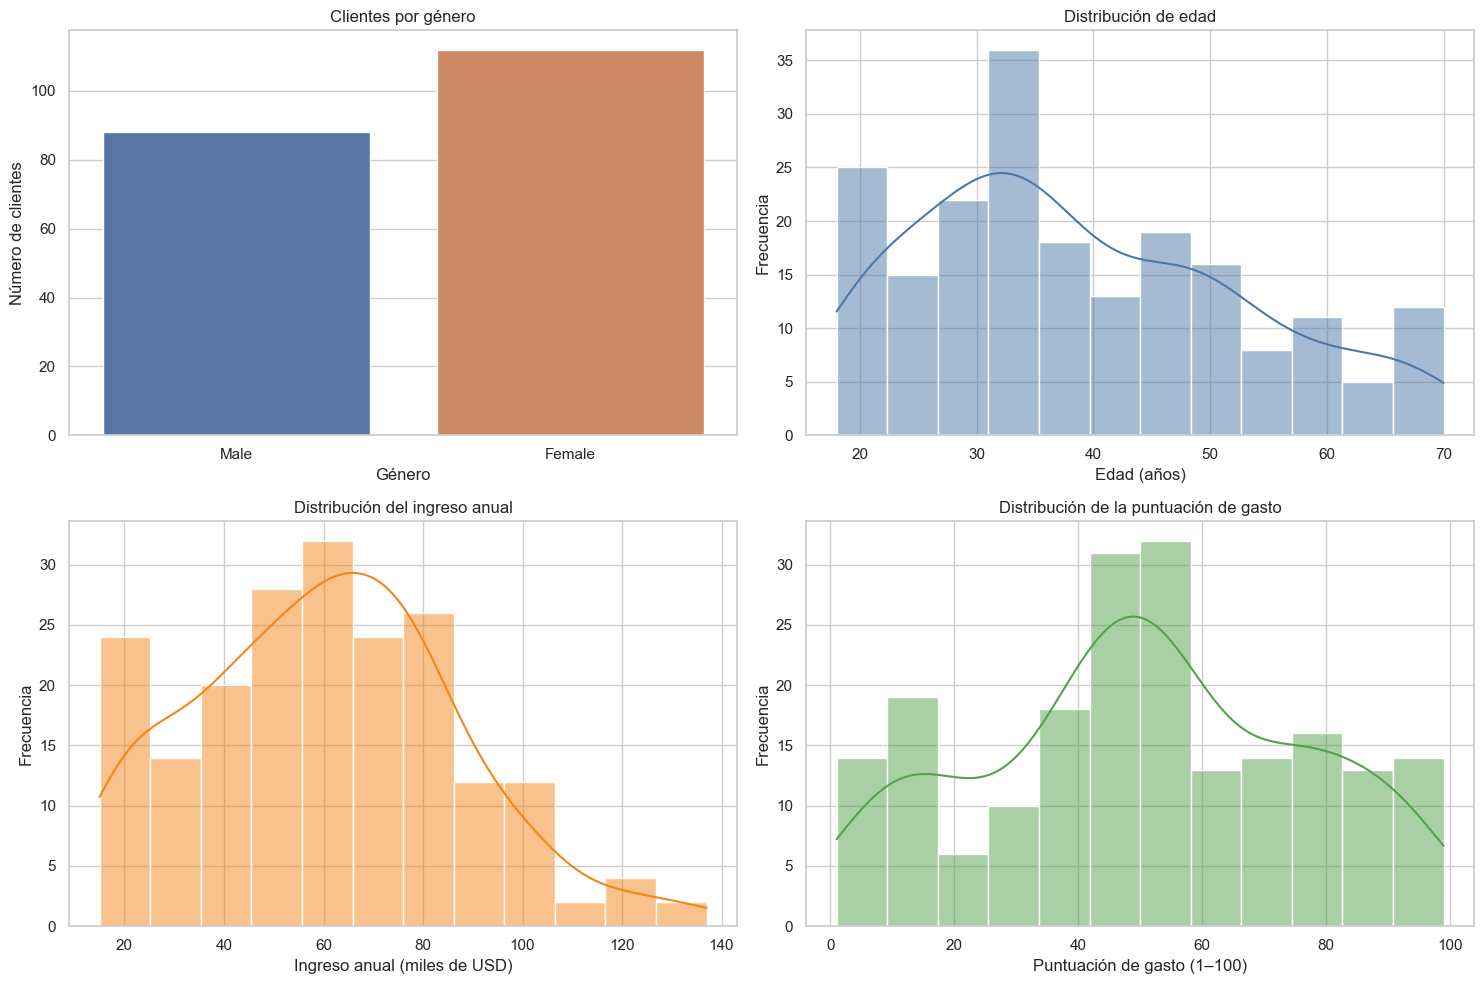

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(data=clientes, x="gender", hue="gender", legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Clientes por género")
axes[0, 0].set_xlabel("Género")
axes[0, 0].set_ylabel("Número de clientes")

sns.histplot(data=clientes, x="age", bins=12, kde=True, color="#4C78A8", ax=axes[0, 1])
axes[0, 1].set_title("Distribución de edad")
axes[0, 1].set_xlabel("Edad (años)")
axes[0, 1].set_ylabel("Frecuencia")

sns.histplot(data=clientes, x="annual_income_k", bins=12, kde=True, color="#F58518", ax=axes[1, 0])
axes[1, 0].set_title("Distribución del ingreso anual")
axes[1, 0].set_xlabel("Ingreso anual (miles de USD)")
axes[1, 0].set_ylabel("Frecuencia")

sns.histplot(data=clientes, x="spending_score", bins=12, kde=True, color="#54A24B", ax=axes[1, 1])
axes[1, 1].set_title("Distribución de la puntuación de gasto")
axes[1, 1].set_xlabel("Puntuación de gasto (1–100)")
axes[1, 1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

**Interpretación univariada.** Hay una mayor cantidad de mujeres que de hombres. Las edades se concentran principalmente entre la adultez joven y media. El ingreso anual presenta grupos en distintos niveles económicos, mientras que la puntuación de gasto está ampliamente distribuida; esta heterogeneidad favorece el uso de clustering para identificar segmentos.

## 7. Valores atípicos

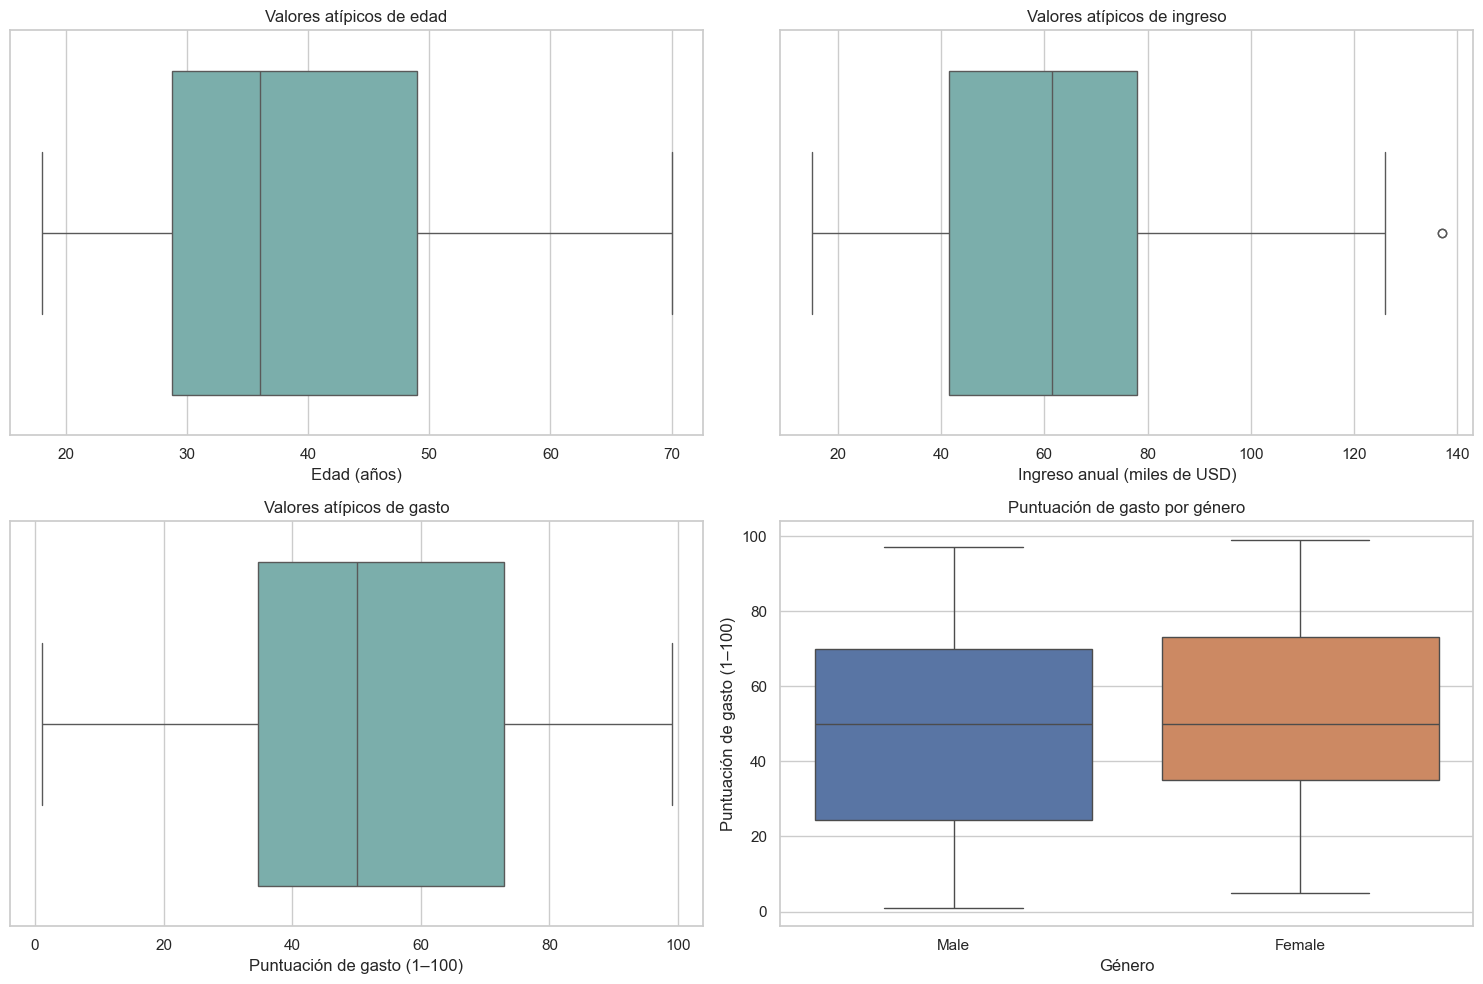

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for variable, eje, titulo, unidad in [
    ("age", axes[0, 0], "Valores atípicos de edad", "Edad (años)"),
    ("annual_income_k", axes[0, 1], "Valores atípicos de ingreso", "Ingreso anual (miles de USD)"),
    ("spending_score", axes[1, 0], "Valores atípicos de gasto", "Puntuación de gasto (1–100)"),
]:
    sns.boxplot(data=clientes, x=variable, color="#72B7B2", ax=eje)
    eje.set_title(titulo)
    eje.set_xlabel(unidad)

sns.boxplot(
    data=clientes,
    x="gender",
    y="spending_score",
    hue="gender",
    legend=False,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Puntuación de gasto por género")
axes[1, 1].set_xlabel("Género")
axes[1, 1].set_ylabel("Puntuación de gasto (1–100)")

plt.tight_layout()
plt.show()

In [11]:
def resumen_atipicos_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    cantidad = int(((serie < limite_inferior) | (serie > limite_superior)).sum())
    return pd.Series({
        "límite_inferior": limite_inferior,
        "límite_superior": limite_superior,
        "cantidad_atípicos": cantidad,
    })

clientes[variables_modelo].apply(resumen_atipicos_iqr).T

,límite_inferior,límite_superior,cantidad_atípicos
age,-1.625,79.375,0.000
annual_income_k,-13.250,132.750,2.000
spending_score,-22.625,130.375,0.000


**Interpretación de atípicos.** Los diagramas de caja muestran que los valores extremos son limitados y plausibles para este contexto. No se eliminan automáticamente: un ingreso alto o una puntuación de gasto extrema puede representar un segmento comercial valioso y no un error de captura.

## 8. Análisis bivariado y multivariado

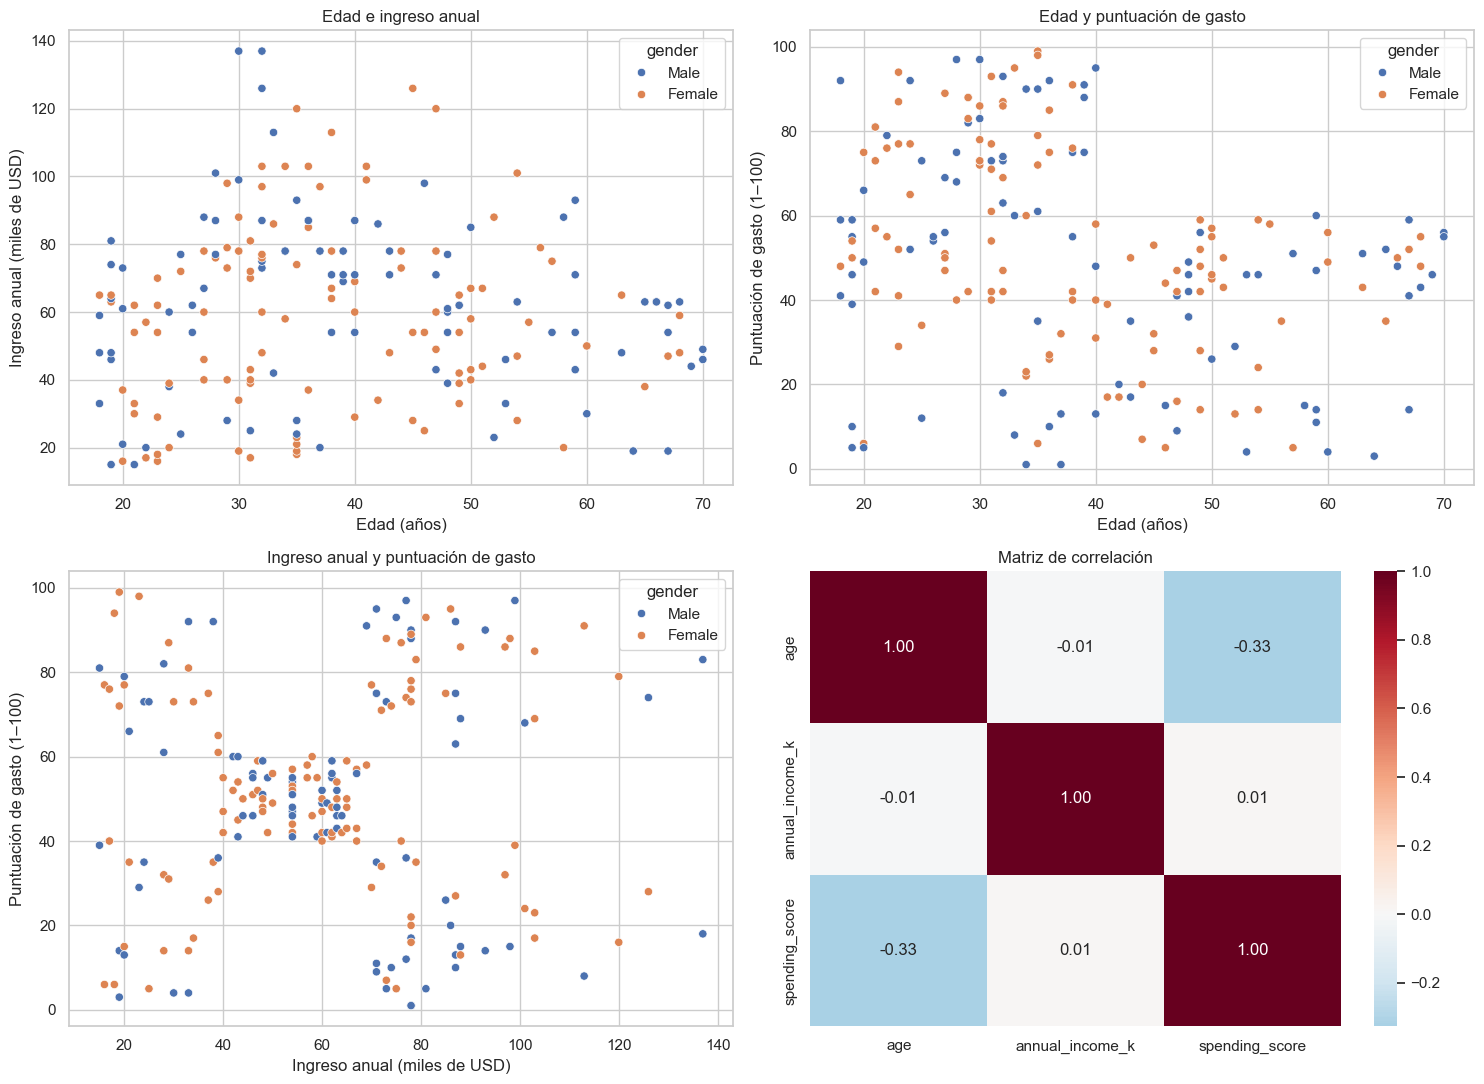

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

sns.scatterplot(data=clientes, x="age", y="annual_income_k", hue="gender", ax=axes[0, 0])
axes[0, 0].set_title("Edad e ingreso anual")
axes[0, 0].set_xlabel("Edad (años)")
axes[0, 0].set_ylabel("Ingreso anual (miles de USD)")

sns.scatterplot(data=clientes, x="age", y="spending_score", hue="gender", ax=axes[0, 1])
axes[0, 1].set_title("Edad y puntuación de gasto")
axes[0, 1].set_xlabel("Edad (años)")
axes[0, 1].set_ylabel("Puntuación de gasto (1–100)")

sns.scatterplot(data=clientes, x="annual_income_k", y="spending_score", hue="gender", ax=axes[1, 0])
axes[1, 0].set_title("Ingreso anual y puntuación de gasto")
axes[1, 0].set_xlabel("Ingreso anual (miles de USD)")
axes[1, 0].set_ylabel("Puntuación de gasto (1–100)")

correlacion = clientes[variables_modelo].corr()
sns.heatmap(correlacion, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1, 1])
axes[1, 1].set_title("Matriz de correlación")

plt.tight_layout()
plt.show()

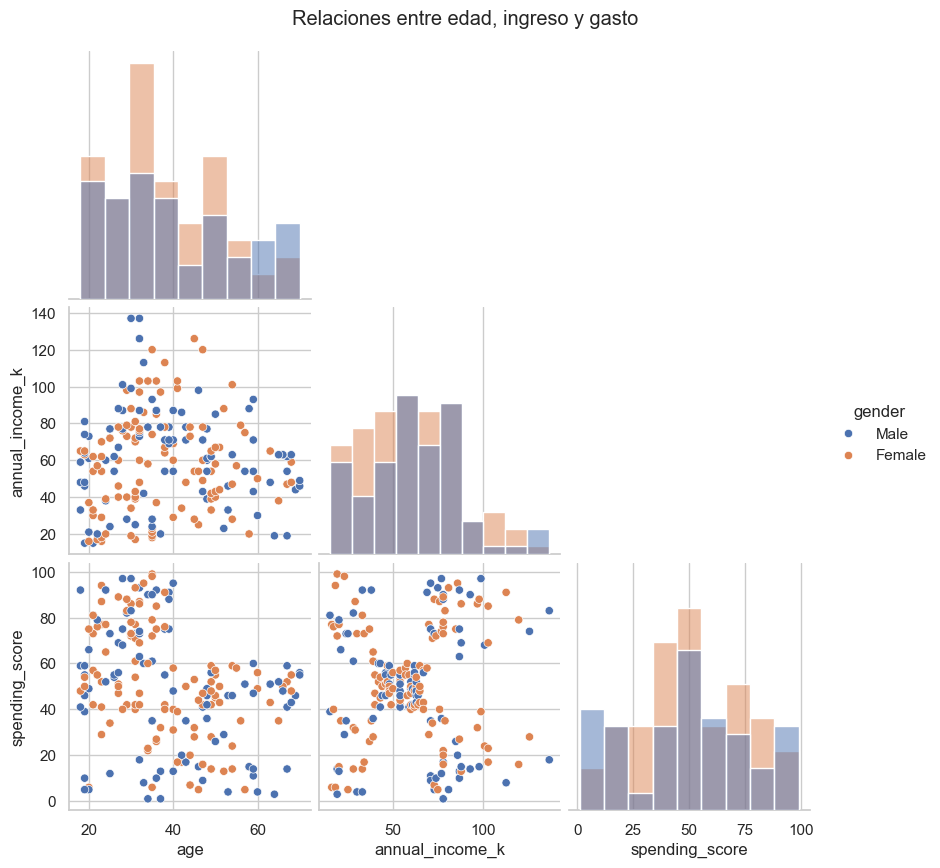

In [13]:
pairplot = sns.pairplot(
    clientes,
    vars=variables_modelo,
    hue="gender",
    corner=True,
    diag_kind="hist",
    height=2.8,
)
pairplot.fig.suptitle("Relaciones entre edad, ingreso y gasto", y=1.03)
plt.show()

**Interpretación multivariada.** Las correlaciones lineales son débiles, por lo que una sola recta no resume adecuadamente el comportamiento de los clientes. La relación entre ingreso y gasto presenta agrupaciones visuales especialmente claras: ingreso bajo/alto combinado con gasto bajo/alto y un grupo central. Edad y gasto también muestran separación entre clientes jóvenes de gasto alto y grupos de mayor edad con gasto moderado o bajo.

## 9. Codificación de la variable de género

In [14]:
codificador_genero = LabelEncoder()
clientes["gender_encoded"] = codificador_genero.fit_transform(clientes["gender"])

mapeo_genero = {
    categoria: int(codigo)
    for categoria, codigo in zip(
        codificador_genero.classes_,
        codificador_genero.transform(codificador_genero.classes_),
    )
}

print("Mapeo obtenido:", mapeo_genero)
clientes[["gender", "gender_encoded"]].drop_duplicates().sort_values("gender_encoded")

Mapeo obtenido: {'Female': 0, 'Male': 1}


,gender,gender_encoded
2,Female,0
0,Male,1


`LabelEncoder` produce el mapeo **Female = 0** y **Male = 1**. Estos números son identificadores de categorías y **no representan un orden jerárquico** ni indican que una categoría sea mayor o mejor que otra. La variable se conserva para análisis descriptivo, pero los modelos mínimos solicitados utilizan únicamente variables cuantitativas.

## 10. Normalización de variables numéricas

In [15]:
escalador_global = StandardScaler()
valores_normalizados = escalador_global.fit_transform(clientes[variables_modelo])

clientes_normalizados = pd.DataFrame(
    valores_normalizados,
    columns=variables_modelo,
    index=clientes.index,
)

comparacion_normalizacion = pd.concat([
    clientes[variables_modelo].assign(version="Original"),
    clientes_normalizados.assign(version="Normalizada"),
])

display(clientes_normalizados.describe().T[["mean", "std", "min", "max"]])

,mean,std,min,max
age,-0.000,1.003,-1.496,2.236
annual_income_k,-0.000,1.003,-1.739,2.918
spending_score,-0.000,1.003,-1.910,1.894


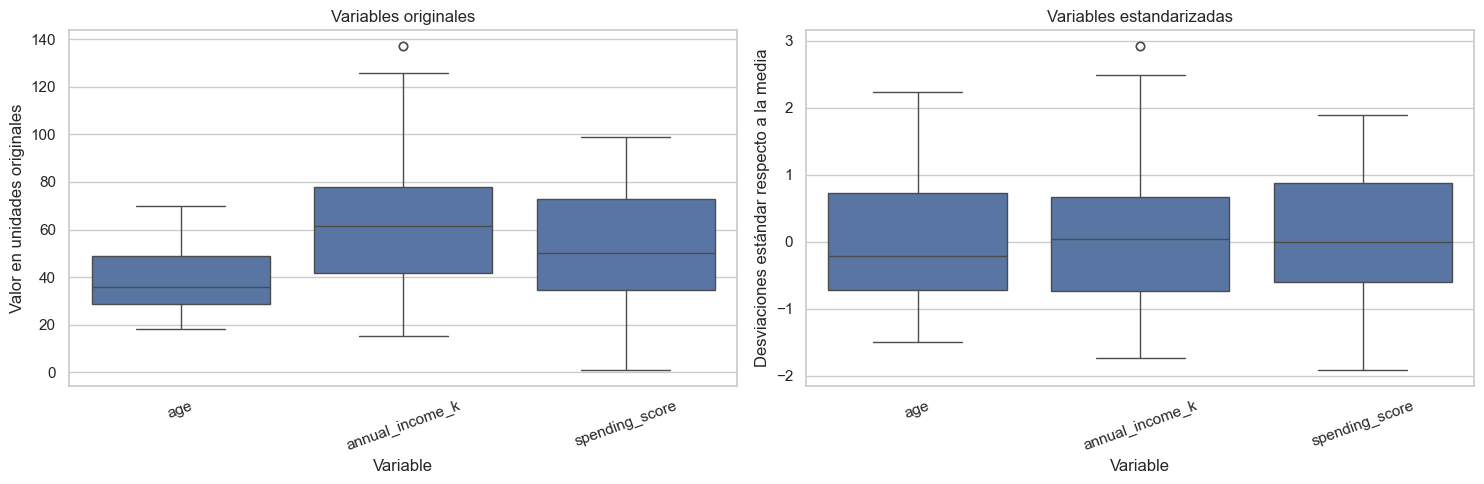

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

original_largo = clientes[variables_modelo].melt(var_name="variable", value_name="valor")
normalizado_largo = clientes_normalizados.melt(var_name="variable", value_name="valor")

sns.boxplot(data=original_largo, x="variable", y="valor", ax=axes[0])
axes[0].set_title("Variables originales")
axes[0].set_xlabel("Variable")
axes[0].set_ylabel("Valor en unidades originales")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(data=normalizado_largo, x="variable", y="valor", ax=axes[1])
axes[1].set_title("Variables estandarizadas")
axes[1].set_xlabel("Variable")
axes[1].set_ylabel("Desviaciones estándar respecto a la media")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

`StandardScaler` transforma cada variable para que tenga media cercana a 0 y desviación estándar cercana a 1. Esto evita que una variable domine la distancia euclidiana únicamente por manejar una escala numérica más amplia. Los valores normalizados no cambian el orden de las observaciones, pero sí el peso relativo de cada dimensión.

## 11. Matrices de características

In [17]:
combinaciones = {
    "Edad e ingreso anual": ["age", "annual_income_k"],
    "Edad y puntuación de gasto": ["age", "spending_score"],
    "Ingreso anual y puntuación de gasto": ["annual_income_k", "spending_score"],
}

matrices = {}
escaladores = {}

for nombre, columnas in combinaciones.items():
    X_original = clientes[columnas].to_numpy(dtype=float)
    escalador = StandardScaler()
    X_normalizado = escalador.fit_transform(X_original)

    matrices[(nombre, "Originales")] = X_original
    matrices[(nombre, "Normalizados")] = X_normalizado
    escaladores[nombre] = escalador

resumen_matrices = pd.DataFrame([
    {
        "combinación": nombre,
        "versión": version,
        "filas": matriz.shape[0],
        "columnas": matriz.shape[1],
    }
    for (nombre, version), matriz in matrices.items()
])
resumen_matrices

,combinación,versión,filas,columnas
0,Edad e ingreso anual,Originales,200,2
1,Edad e ingreso anual,Normalizados,200,2
2,Edad y puntuación de gasto,Originales,200,2
3,Edad y puntuación de gasto,Normalizados,200,2
4,Ingreso anual y puntuación de gasto,Originales,200,2
5,Ingreso anual y puntuación de gasto,Normalizados,200,2


## 12. Método del codo y coeficiente de silueta

El **método del codo** compara la inercia para varios valores de `k`. La inercia siempre disminuye al añadir clústeres; se busca el punto a partir del cual la mejora adicional deja de ser pronunciada.

El **coeficiente de silueta** varía entre -1 y 1. Valores altos indican que las observaciones están próximas a su propio clúster y separadas de los demás. Se evalúan valores de `k` entre 2 y 10. La selección final utiliza el mayor coeficiente de silueta y se contrasta visualmente con el codo.

In [18]:
def evaluar_kmeans(matriz, combinacion, version, rango_k=range(2, 11)):
    resultados = []
    for k in rango_k:
        modelo = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=20,
            max_iter=300,
            random_state=42,
        )
        etiquetas = modelo.fit_predict(matriz)
        resultados.append({
            "combinación": combinacion,
            "versión": version,
            "k": k,
            "inercia": modelo.inertia_,
            "silueta": silhouette_score(matriz, etiquetas),
        })
    return pd.DataFrame(resultados)


metricas_k = pd.concat([
    evaluar_kmeans(matriz, nombre, version)
    for (nombre, version), matriz in matrices.items()
], ignore_index=True)

metricas_k.head(12)

,combinación,versión,k,inercia,silueta
0,Edad e ingreso anual,Originales,2,"87,121.566",0.426
1,Edad e ingreso anual,Originales,3,"59,486.961",0.425
2,Edad e ingreso anual,Originales,4,"39,502.779",0.434
3,Edad e ingreso anual,Originales,5,"31,651.381",0.404
4,Edad e ingreso anual,Originales,6,"25,399.022",0.396
5,Edad e ingreso anual,Originales,7,"21,774.976",0.386
6,Edad e ingreso anual,Originales,8,"18,864.876",0.394
7,Edad e ingreso anual,Originales,9,"15,993.236",0.396
8,Edad e ingreso anual,Originales,10,"13,697.902",0.420
9,Edad e ingreso anual,Normalizados,2,250.588,0.371


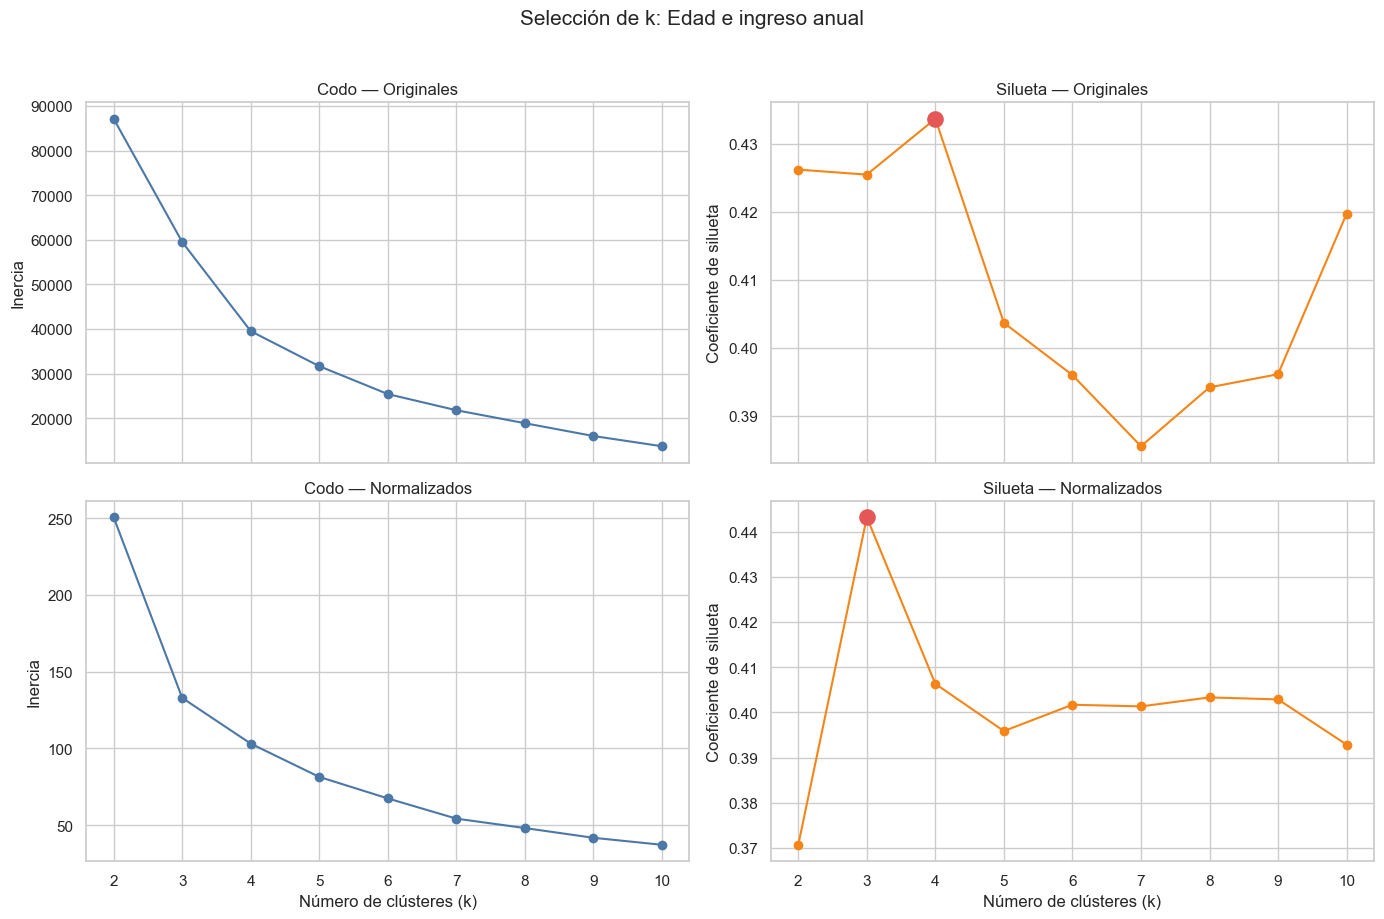

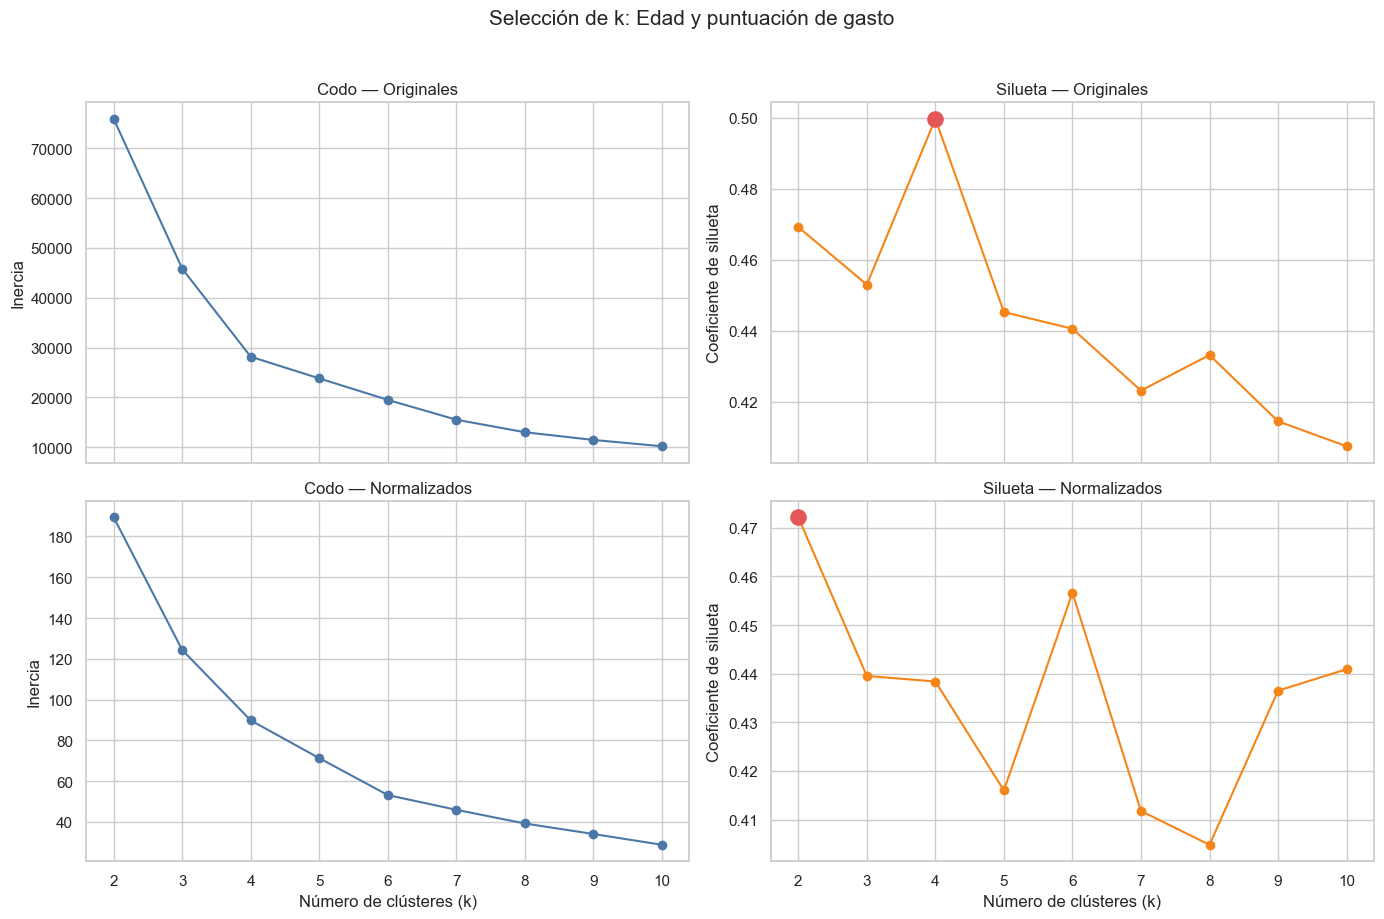

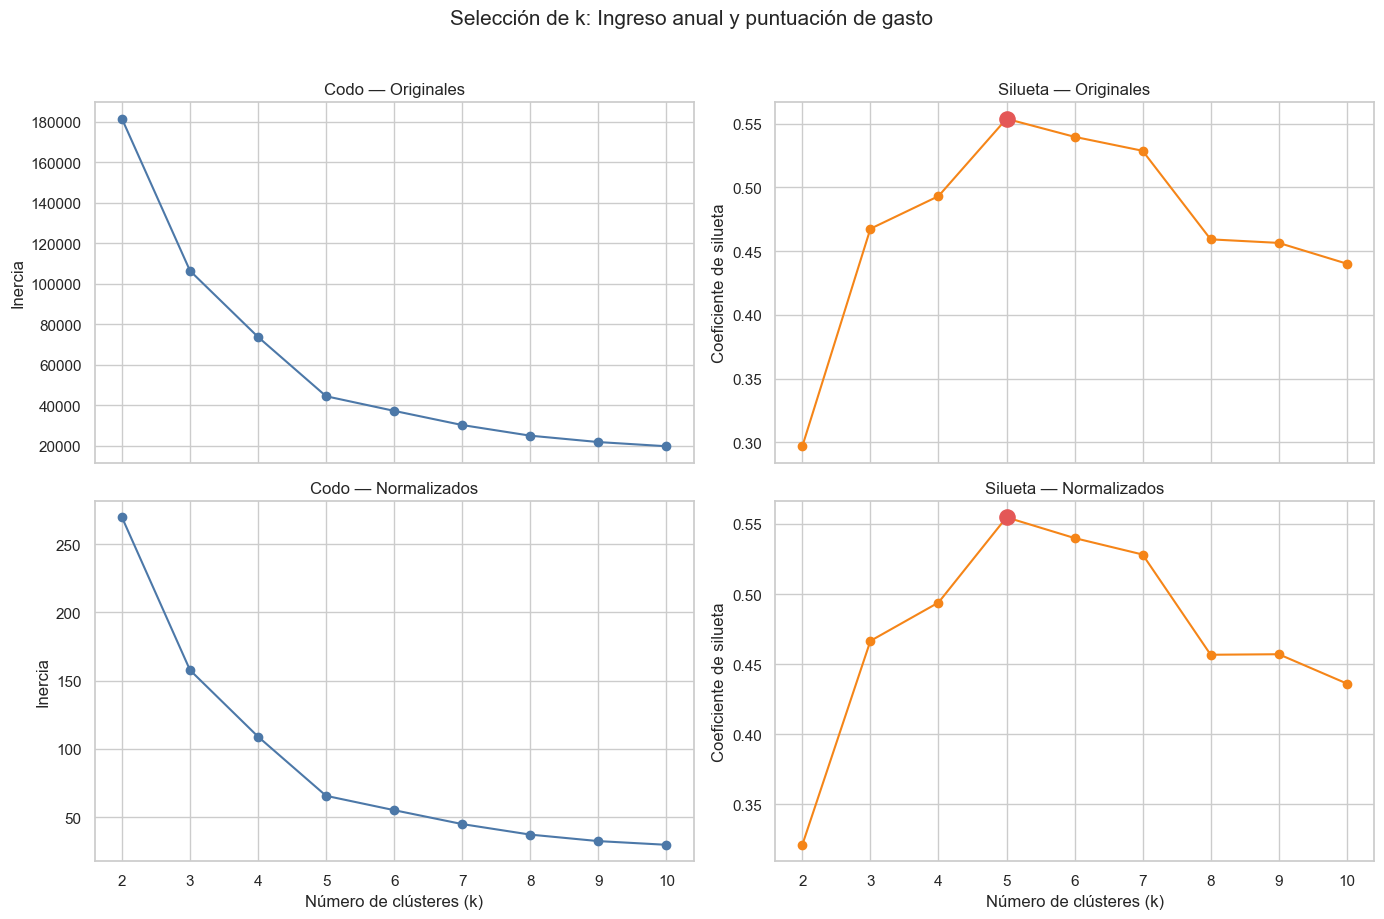

In [19]:
for nombre in combinaciones:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

    for fila, version in enumerate(["Originales", "Normalizados"]):
        datos = metricas_k.query("combinación == @nombre and versión == @version")

        axes[fila, 0].plot(datos["k"], datos["inercia"], marker="o", color="#4C78A8")
        axes[fila, 0].set_title(f"Codo — {version}")
        axes[fila, 0].set_ylabel("Inercia")
        axes[fila, 0].set_xticks(datos["k"])

        axes[fila, 1].plot(datos["k"], datos["silueta"], marker="o", color="#F58518")
        mejor = datos.loc[datos["silueta"].idxmax()]
        axes[fila, 1].scatter(mejor["k"], mejor["silueta"], s=120, color="#E45756", zorder=3)
        axes[fila, 1].set_title(f"Silueta — {version}")
        axes[fila, 1].set_ylabel("Coeficiente de silueta")
        axes[fila, 1].set_xticks(datos["k"])

    axes[1, 0].set_xlabel("Número de clústeres (k)")
    axes[1, 1].set_xlabel("Número de clústeres (k)")
    fig.suptitle(f"Selección de k: {nombre}", fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()

In [20]:
indices_mejores = metricas_k.groupby(["combinación", "versión"])["silueta"].idxmax()
seleccion_k = (
    metricas_k.loc[indices_mejores, ["combinación", "versión", "k", "inercia", "silueta"]]
    .sort_values(["combinación", "versión"])
    .reset_index(drop=True)
)
seleccion_k

,combinación,versión,k,inercia,silueta
0,Edad e ingreso anual,Normalizados,3,132.855,0.443
1,Edad e ingreso anual,Originales,4,"39,502.779",0.434
2,Edad y puntuación de gasto,Normalizados,2,189.387,0.472
3,Edad y puntuación de gasto,Originales,4,"28,165.584",0.500
4,Ingreso anual y puntuación de gasto,Normalizados,5,65.568,0.555
5,Ingreso anual y puntuación de gasto,Originales,5,"44,448.455",0.554


### Justificación del número de clústeres

- **Edad e ingreso anual:** los datos originales favorecen `k=4`; al estandarizar, la silueta favorece `k=3`. La diferencia muestra que el ingreso, por su escala mayor, tiene más influencia sin normalización.
- **Edad y puntuación de gasto:** los datos originales favorecen `k=4`; en los normalizados la separación más compacta ocurre con `k=2`. Este resultado resume principalmente clientes jóvenes frente a clientes de mayor edad, aunque una segmentación con más grupos puede ser útil si el objetivo comercial requiere mayor detalle.
- **Ingreso anual y puntuación de gasto:** `k=5` es la solución más clara en ambas versiones. El codo es visible alrededor de cinco clústeres y la silueta alcanza ahí su mejor valor. Esta combinación produce perfiles comerciales fáciles de interpretar.

La cantidad elegida no es una verdad universal: depende de las variables, su escala y el nivel de detalle útil para el negocio.

## 13. Modelos finales de K-Means

In [21]:
modelos_finales = {}
reporte_modelos = []

for fila in seleccion_k.itertuples(index=False):
    nombre = fila[0]
    version = fila[1]
    k = int(fila[2])
    matriz = matrices[(nombre, version)]

    modelo = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        max_iter=300,
        random_state=42,
    )
    etiquetas = modelo.fit_predict(matriz)
    modelos_finales[(nombre, version)] = (modelo, etiquetas)

    reporte_modelos.append({
        "combinación": nombre,
        "versión": version,
        "k": k,
        "inercia": modelo.inertia_,
        "silueta": silhouette_score(matriz, etiquetas),
        "iteraciones": modelo.n_iter_,
        "init": modelo.init,
        "n_init": modelo.n_init,
        "max_iter": modelo.max_iter,
        "random_state": modelo.random_state,
    })

reporte_modelos = pd.DataFrame(reporte_modelos)
reporte_modelos

,combinación,versión,k,inercia,silueta,iteraciones,init,n_init,max_iter,random_state
0,Edad e ingreso anual,Normalizados,3,132.855,0.443,5,k-means++,20,300,42
1,Edad e ingreso anual,Originales,4,"39,502.779",0.434,6,k-means++,20,300,42
2,Edad y puntuación de gasto,Normalizados,2,189.387,0.472,2,k-means++,20,300,42
3,Edad y puntuación de gasto,Originales,4,"28,165.584",0.500,8,k-means++,20,300,42
4,Ingreso anual y puntuación de gasto,Normalizados,5,65.568,0.555,4,k-means++,20,300,42
5,Ingreso anual y puntuación de gasto,Originales,5,"44,448.455",0.554,4,k-means++,20,300,42


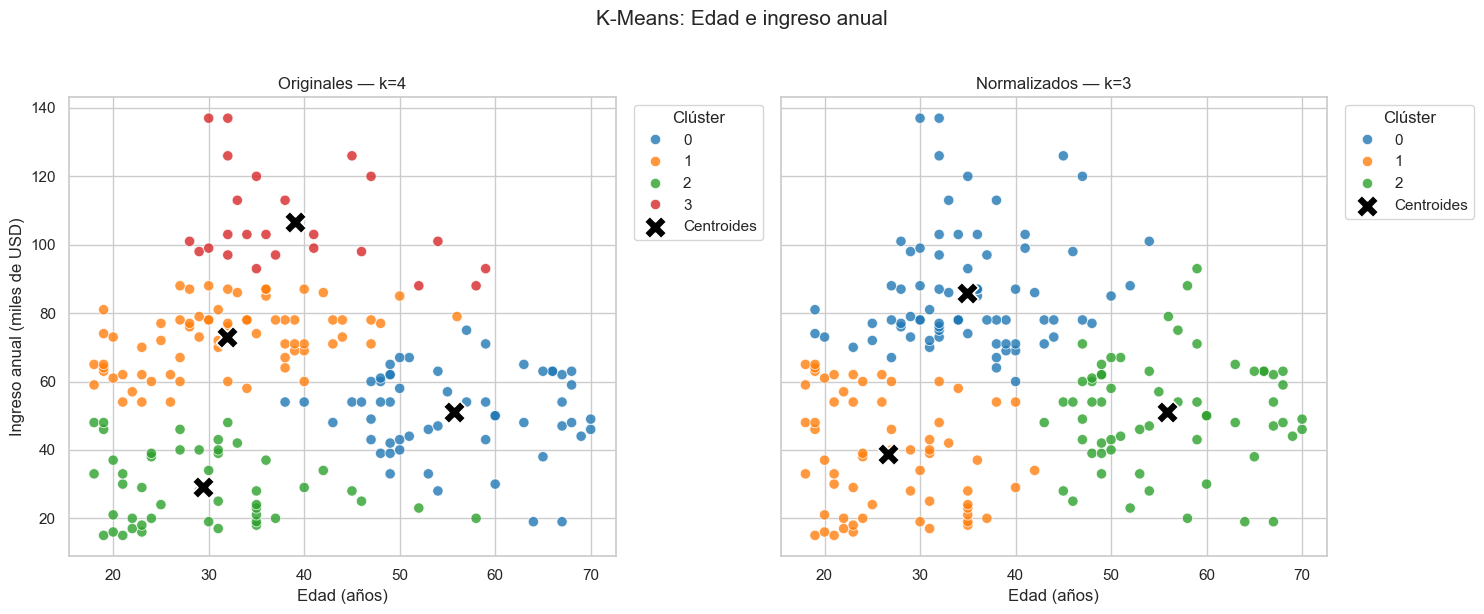

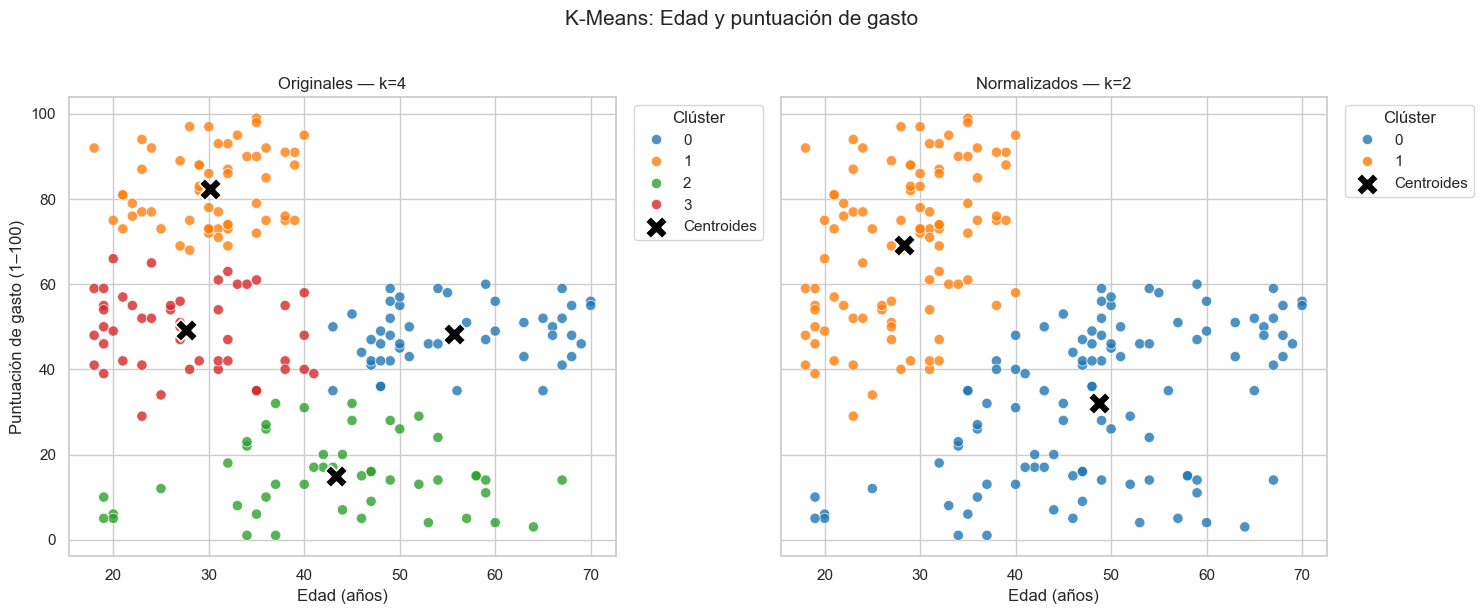

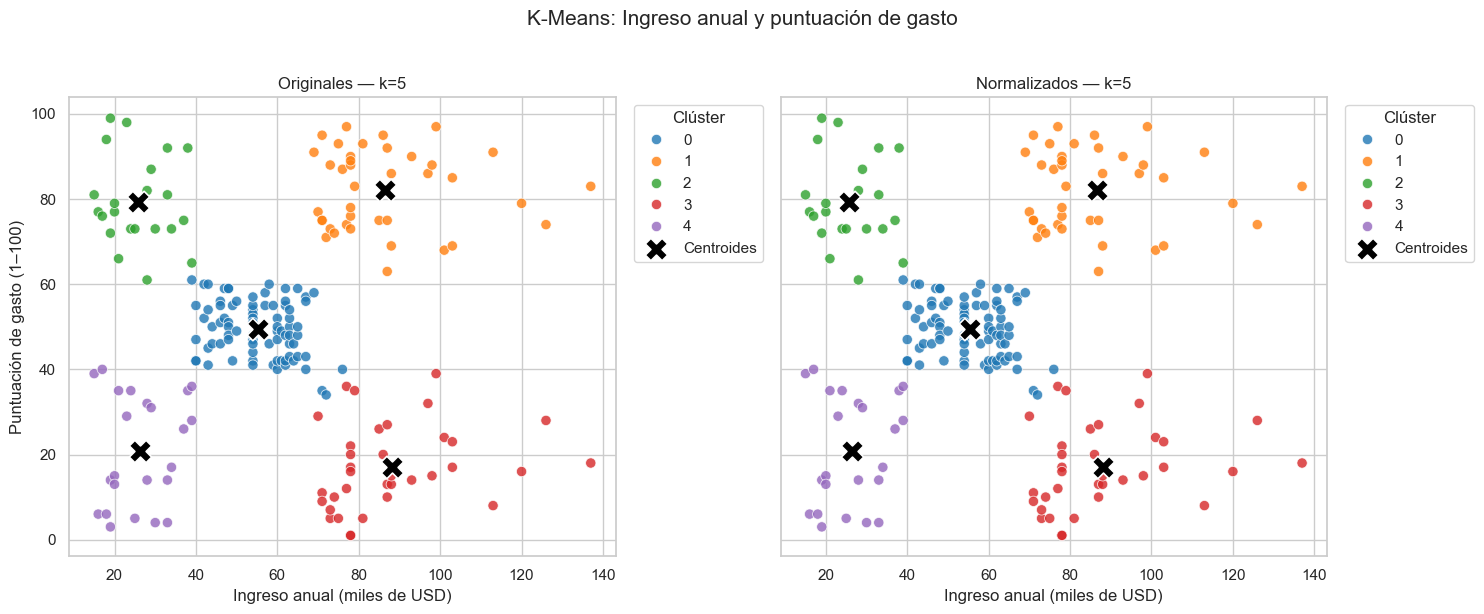

In [22]:
etiquetas_ejes = {
    "age": "Edad (años)",
    "annual_income_k": "Ingreso anual (miles de USD)",
    "spending_score": "Puntuación de gasto (1–100)",
}

for nombre, columnas in combinaciones.items():
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

    for eje, version in zip(axes, ["Originales", "Normalizados"]):
        modelo, etiquetas = modelos_finales[(nombre, version)]
        puntos_originales = clientes[columnas].to_numpy(dtype=float)

        if version == "Normalizados":
            centroides = escaladores[nombre].inverse_transform(modelo.cluster_centers_)
        else:
            centroides = modelo.cluster_centers_

        sns.scatterplot(
            x=puntos_originales[:, 0],
            y=puntos_originales[:, 1],
            hue=etiquetas,
            palette="tab10",
            s=55,
            alpha=0.8,
            legend="full",
            ax=eje,
        )
        eje.scatter(
            centroides[:, 0],
            centroides[:, 1],
            marker="X",
            s=260,
            c="black",
            edgecolors="white",
            linewidths=1.2,
            label="Centroides",
        )
        eje.set_title(f"{version} — k={modelo.n_clusters}")
        eje.set_xlabel(etiquetas_ejes[columnas[0]])
        eje.set_ylabel(etiquetas_ejes[columnas[1]])
        eje.legend(title="Clúster", bbox_to_anchor=(1.02, 1), loc="upper left")

    fig.suptitle(f"K-Means: {nombre}", fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()

## 14. Perfiles de clientes

In [23]:
nombre_perfil = "Ingreso anual y puntuación de gasto"
modelo_perfil, etiquetas_perfil = modelos_finales[(nombre_perfil, "Normalizados")]

clientes_segmentados = clientes.copy()
clientes_segmentados["cluster"] = etiquetas_perfil

perfiles = (
    clientes_segmentados.groupby("cluster")
    .agg(
        clientes=("customer_id", "count"),
        edad_media=("age", "mean"),
        ingreso_medio_k=("annual_income_k", "mean"),
        gasto_medio=("spending_score", "mean"),
        porcentaje_mujeres=("gender", lambda s: 100 * s.eq("Female").mean()),
    )
    .round(2)
)

def describir_segmento(fila):
    ingreso = fila["ingreso_medio_k"]
    gasto = fila["gasto_medio"]
    if ingreso >= 70 and gasto >= 60:
        return "Alto valor: ingreso y gasto altos"
    if ingreso >= 70 and gasto <= 40:
        return "Oportunidad: ingreso alto y gasto bajo"
    if ingreso <= 45 and gasto >= 60:
        return "Entusiastas: ingreso bajo y gasto alto"
    if ingreso <= 45 and gasto <= 40:
        return "Cautelosos: ingreso y gasto bajos"
    return "Convencionales: ingreso y gasto medios"

perfiles["perfil"] = perfiles.apply(describir_segmento, axis=1)
perfiles.sort_values("ingreso_medio_k")

,clientes,edad_media,ingreso_medio_k,gasto_medio,porcentaje_mujeres,perfil
cluster,,,,,,
2,22,25.270,25.730,79.360,59.090,Entusiastas: ingreso bajo y gasto alto
4,23,45.220,26.300,20.910,60.870,Cautelosos: ingreso y gasto bajos
0,81,42.720,55.300,49.520,59.260,Convencionales: ingreso y gasto medios
1,39,32.690,86.540,82.130,53.850,Alto valor: ingreso y gasto altos
3,35,41.110,88.200,17.110,45.710,Oportunidad: ingreso alto y gasto bajo


### Interpretación de los segmentos

1. **Alto valor:** clientes con ingreso y gasto altos. Conviene fortalecer su lealtad mediante beneficios exclusivos y atención personalizada.
2. **Oportunidad:** tienen capacidad económica, pero su gasto es bajo. Se pueden investigar barreras de compra y diseñar campañas de activación.
3. **Entusiastas:** muestran gasto elevado a pesar de ingresos menores. Son sensibles a promociones, lanzamientos y programas de recompensas.
4. **Cautelosos:** combinan ingreso y gasto bajos. Requieren ofertas accesibles y comunicación centrada en valor.
5. **Convencionales:** presentan niveles medios de ingreso y gasto. Constituyen una base estable para campañas generales.

Los números de clúster son arbitrarios; la interpretación depende de los centroides, no del identificador asignado por K-Means.

## 15. Comparación entre datos originales y normalizados

In [24]:
comparacion_modelos = []

for nombre in combinaciones:
    modelo_original, etiquetas_originales = modelos_finales[(nombre, "Originales")]
    modelo_normalizado, etiquetas_normalizadas = modelos_finales[(nombre, "Normalizados")]

    comparacion_modelos.append({
        "combinación": nombre,
        "k_original": modelo_original.n_clusters,
        "k_normalizado": modelo_normalizado.n_clusters,
        "ARI_original_vs_normalizado": adjusted_rand_score(
            etiquetas_originales, etiquetas_normalizadas
        ),
    })

comparacion_modelos = pd.DataFrame(comparacion_modelos)
comparacion_modelos

,combinación,k_original,k_normalizado,ARI_original_vs_normalizado
0,Edad e ingreso anual,4,3,0.543
1,Edad y puntuación de gasto,4,2,0.442
2,Ingreso anual y puntuación de gasto,5,5,1.000


El **índice Rand ajustado** (*Adjusted Rand Index, ARI*) compara las asignaciones de dos particiones: 1 indica coincidencia total y valores cercanos a 0 indican poca semejanza. La normalización puede cambiar el número de clústeres y la pertenencia de los clientes, sobre todo cuando las variables manejan escalas distintas. En ingreso frente a gasto, ambas escalas son parecidas y la solución de cinco segmentos resulta estable; en combinaciones con edad, la estandarización cambia el peso relativo de las dimensiones.

## 16. Conclusiones

La práctica permitió aplicar un proceso completo de aprendizaje no supervisado: inspección, limpieza, análisis exploratorio, codificación, normalización, selección de `k`, entrenamiento y evaluación. El dataset es pequeño y limpio, pero contiene suficiente variación en edad, ingreso y gasto para formar segmentos interpretables.

La combinación de **ingreso anual y puntuación de gasto** produjo la segmentación comercial más clara, con cinco perfiles: alto valor, oportunidad, entusiastas, cautelosos y convencionales. Los resultados de edad con ingreso o gasto fueron más sensibles a la normalización, confirmando que K-Means depende de la escala porque utiliza distancias euclidianas.

Usar más clústeres reduce la inercia, pero puede fragmentar grupos sin aportar valor de negocio. Usar muy pocos simplifica la lectura, aunque oculta perfiles distintos. Por ello se combinaron el codo, la silueta y la interpretación de los centroides.

### Limitaciones

- K-Means requiere decidir `k` antes del entrenamiento.
- Supone grupos aproximadamente compactos y de forma esférica.
- Es sensible a la escala, inicialización y valores extremos.
- Los identificadores de clúster no tienen un orden natural.
- El dataset solo contiene 200 clientes y pocas variables; no incluye historial de compras, ubicación, frecuencia, rentabilidad ni periodo temporal.
- Los segmentos son exploratorios y deben validarse con objetivos y datos reales del negocio antes de tomar decisiones.

## 17. Comprobaciones finales

In [25]:
comprobaciones = {
    "dataset_con_200_registros": len(clientes) == 200,
    "cinco_columnas_originales": clientes_original.shape[1] == 5,
    "sin_nulos": not clientes.isna().any().any(),
    "sin_duplicados": not clientes.duplicated().any(),
    "ids_unicos": clientes["customer_id"].is_unique,
    "genero_codificado": "gender_encoded" in clientes.columns,
    "tres_combinaciones": len(combinaciones) == 3,
    "seis_matrices": len(matrices) == 6,
    "seis_modelos_finales": len(modelos_finales) == 6,
    "metricas_completas": {"inercia", "silueta", "iteraciones"}.issubset(reporte_modelos.columns),
}

resultado_final = pd.Series(comprobaciones, name="cumple")
display(resultado_final.to_frame())

assert resultado_final.all(), "Existe al menos una comprobación pendiente."
print("✅ Notebook ejecutado completamente y sin comprobaciones pendientes.")

,cumple
dataset_con_200_registros,True
cinco_columnas_originales,True
sin_nulos,True
sin_duplicados,True
ids_unicos,True
genero_codificado,True
tres_combinaciones,True
seis_matrices,True
seis_modelos_finales,True
metricas_completas,True


✅ Notebook ejecutado completamente y sin comprobaciones pendientes.


## Integración con Git y GitHub

La práctica se desarrolla en la rama `practica09`. Los archivos se fusionarán con `main` únicamente después de revisar el Notebook ejecutado, el README, el CSV y las evidencias. Los commits deben describir avances concretos, por ejemplo: estructura inicial, EDA, modelos K-Means y documentación final.